# Собираем исходник с Яндекс Диска

In [1]:
import yadisk
import pandas as pd
from io import BytesIO
import os 
from dotenv import load_dotenv

load_dotenv()

TOKEN = os.getenv("YANDEX_TOKEN")
DISK_PATH = os.getenv("DISK_PATH")

print(f"Токен загружен: {bool(TOKEN)}")

# Настройки отображения pandas, чтобы датафрейм выводился целиком
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

Токен загружен: True


In [5]:
def read_xlsx_from_personal_disk(token, disk_path, sheet_name=0):
    """
    Скачивает Excel с Яндекс.Диска и читает указанный лист.
    Если указанный sheet_name не найден, читает первый доступный лист.
    """
    y = yadisk.YaDisk(token=token)
    
    if not y.check_token():
        raise Exception("Неверный OAuth-токен")
        
    if not y.exists(disk_path):
        raise Exception(f"Файл не найден по пути: {disk_path}")

    try:
        # Создаем буфер в памяти и скачиваем туда файл
        buffer = BytesIO()
        y.download(disk_path, buffer)
        buffer.seek(0)
        
        # Открываем Excel-файл через pd.ExcelFile для инспекции листов
        excel_file = pd.ExcelFile(buffer, engine='calamine')
        available_sheets = excel_file.sheet_names
        
        target_sheet = sheet_name
        
        # Если переданное название листа — строка и его нет в книге
        if isinstance(sheet_name, str) and sheet_name not in available_sheets:
            first_sheet = available_sheets[0]
            print(f"⚠️ Предупреждение: Лист '{sheet_name}' не найден в файле.")
            print(f"Доступные листы: {available_sheets}")
            print(f"🔄 Загружается первый доступный лист: '{first_sheet}'")
            target_sheet = 0  # Выбираем первый лист по индексу
            
        # Читаем целевой лист
        df = excel_file.parse(sheet_name=target_sheet)
        return df
        
    except Exception as e:
        raise Exception(f"Ошибка при загрузке или чтении Excel: {e}")

In [7]:
# TARGET_SHEET = "Закупки"

TARGET_SHEET = "ОС Главная"

try:
    print(f"Загрузка листа: '{TARGET_SHEET}'...")
    data_frame = read_xlsx_from_personal_disk(TOKEN, DISK_PATH, sheet_name=TARGET_SHEET)
    
    print(f"Успешно прочитано строк: {len(data_frame)}\n")
    print(data_frame.head(20))
    
except Exception as error:
    print(f"Произошла ошибка: {error}")

Загрузка листа: 'ОС Главная'...
⚠️ Предупреждение: Лист 'ОС Главная' не найден в файле.
Доступные листы: ['Лист1']
🔄 Загружается первый доступный лист: 'Лист1'
Успешно прочитано строк: 1000

     №      Код      Код ОКПД2                                       Номенклатура       QR код              Статус                Проект МТО/Услуга      Цена  Кол-во    Сумма  Упаковка Ед. изм.      Строка плана закупки  План потребности              План МТР  Отдел МТО    Куратор МТО Счет поставщика согласован  Цена финальная  Сумма финальная   Заявка на закупку           Заявка на оплату  Приходный ордер   Оплачено   Получено со склада   Отменено  Ссылка  Остаток Место хранения  Списано
0    1  2867825  00.00.00.0001                       Скотч упаковочный прозрачный   МТО1222222      Ожидает оплаты         ООО БибаИБоба     Услуга  26874.96      59  1730.77       NaN        м  утверждена от 23.06.2026               NaN  00-000 от 24.09.2032        111    Иванов И.И.                        Нет   

In [ ]:
# # Оба листа в виде словаря

# dfs = read_xlsx_from_personal_disk(TOKEN, DISK_PATH, sheet_name=["Закупки", "ОС Главная"])
# # Использование:
# print(dfs["Закупки"])
# print(dfs["ОС Главная"])

# Пересобираем эксельку на основании исходника (для полноты и разнообразия данных)

## На основе заданной структуры

In [9]:
import random
import numpy as np
from datetime import datetime, timedelta
import pandas as pd

# Фиксируем seed для воспроизводимости (опционально)
random.seed(42)

COUNT = 1000

In [5]:
# 1. Генерация уникальных 7-значных кодов
codes = random.sample(range(1000000, 9999999), COUNT)

# 2. Генерация уникальных кодов ОКПД2
okpd_list = [f"00.00.00.{i:04d}" for i in range(1, COUNT + 1)]

# Выборки для генерации номенклатуры
categories = [
    # Электроника и компоненты
    "Транзистор IRF1404", "Резистор 10 кОм (упаковка 100 шт)", "Светодиод 5мм (набор)", 
    "Конденсатор электролитический 1000мкФ", "Плата Arduino Nano V3.0", "Модуль ESP32 Wi-Fi/Bluetooth", 
    "Полетный контроллер Pixhawk 2.4.8", "Датчик давления воды MS5837", "Бесщеточный мотор A2212 1000KV", 
    "Регулятор оборотов ESC 20A BLHeli", "BMS плата защиты 3S 40A", "Преобразователь напряжения XL6009 DC-DC",
    "Кабель монтажный МГТФ 0.35 мм²", "Разъемы XT60 (пара «папа-мама»)", "Комплект Dupont коннекторов",

    # 3D-печать и расходники
    "Пластик PLA 1.75 мм (Черный, 1 кг)", "Пластик PETG 1.75 мм (Синий, 1 кг)", "Пластик ABS 1.75 мм (Серый, 1 кг)",
    "Сопло для 3D принтера E3D V6 0.4 мм", "Термобарьер для экструдера", "Шаговый двигатель NEMA 17", 
    "Стекло для стола 3D принтера 235x235", "Лента малярная термостойкая 50мм", "Ремень зубчатый GT2 (пог. метр)",

    # Инструменты и паяльное оборудование
    "Паяльник 120 Вт с регулировкой", "Набор сменных жал T12 (5 шт)", "Припой ПОС-61 с канифолью (100г)", 
    "Флюс паяльный ЛТИ-120 (флакон)", "Спирто-канифольный флюс (СКФ)", "Набор прецизионных отверток (24 в 1)", 
    "Кусачки бокорезы мини", "Штангенциркуль цифровой 150мм", "Мультиметр цифровой с прозвонкой", 
    "Осциллограф цифровой портативный", "Мини-паяльник USB", "Губка латунная для очистки жал",

    # Крепеж, металлопрокат и материалы
    "Винт M3x10 с цилиндрической головкой (100 шт)", "Гайка M3 самоконтрящаяся (100 шт)", "Шайба гровер M3 (100 шт)", 
    "Профиль алюминиевый конструкционный 2020 (1 м)", "Трубка термоусадочная 3мм (упаковка 5м)", 
    "Стяжки нейлоновые кабельные 100х2.5 мм (упак.)", "Лист стеклотекстолита фольгированного", 
    "Диск отрезной абразивный по металлу", "Пилка по металлу для лобзика (набор)",

    # Канцелярия и общие хозтовары
    "Маркеры для магнитной доски (набор 4 цвета)", "Маркеры перманентные черные (упаковка 10 шт)", 
    "Канцелярский нож усиленный с лезвиями", "Бумага для принтера А4 (пачка 500 листов)", 
    "Клей-карандаш канцелярский", "Скотч упаковочный прозрачный", "Блокнот для записей в клетку",
    "Очки защитные прозрачные", "Перчатки рабочие с полиуретановым покрытием (пара)"
]

statuses = ["Получено со склада", "Согласовано", "В доставке", "Ожидает оплаты", "Отменено"]
projects = ["ООО БибаИБоба", "Проект Робототехника", "НИОКР-2026", "Модернизация-МТО", "Цех №4"]
mto_types = ["МТО", "Услуга"]
units = ["шт.", "л.", "кг", "компл.", "упак.", "м"]
departments = ["101", "105", "111", "204", "302"]
curators = ["Иванов И.И.", "Петров П.П.", "Сидоров С.С.", "Смирнова А.В.", "Кузнецов М.Ю."]

data = []
start_date = datetime(2026, 1, 1)

for i in range(COUNT):
    code = codes[i]
    okpd = okpd_list[i]
    item_name = random.choice(categories)
    status = random.choice(statuses)
    project = random.choice(projects)
    mto = random.choice(mto_types)
    
    # Экономические показатели
    price = round(random.uniform(100, 50000), 2)
    quantity = random.randint(1, 100)
    total_price = round(price * quantity, 2)
    final_price = round(total_price * random.uniform(1.02, 1.15), 2)  # с учетом наценок/логистики
    unit = random.choice(units)
    
    # Даты и статус согласования
    random_days = random.randint(1, 250)
    base_date = start_date + timedelta(days=random_days)
    date_str = base_date.strftime("%d.%m.%Y")
    
    approved_plan = f"утверждена от {date_str}" if random.random() > 0.1 else "не утверждена"
    invoice_approved = random.choice(["Да", "Нет"])
    dept = random.choice(departments)
    curator = random.choice(curators)
    
    payment_request = f"АБ00-{random.randint(100000, 999999)} от {date_str}"
    
    # Связная логика статусов, дат и мест хранения
    paid_date = ""
    received_date = ""
    canceled_date = ""
    storage = ""
    
    if status == "Отменено":
        canceled_date = (base_date + timedelta(days=random.randint(1, 5))).strftime("%d.%m.%Y")
        storage = ""  # Место хранения пустое при отмене
    elif status == "Получено со склада":
        pay_d = base_date + timedelta(days=random.randint(1, 3))
        rec_d = pay_d + timedelta(days=random.randint(1, 10))
        paid_date = pay_d.strftime("%d.%m.%Y")
        received_date = f"Получено {rec_d.strftime('%d.%m.%Y')}"
        storage = f"{random.randint(10, 99)}В{random.randint(0, 9)}"
    elif status in ["Согласовано", "В доставке"]:
        if random.random() > 0.3:
            paid_date = (base_date + timedelta(days=random.randint(1, 5))).strftime("%d.%m.%Y")
    
    data.append({
        "Код": code,
        "Код ОКПД2": okpd,
        "Номенклатура": item_name,
        "Статус": status,
        "Проект": project,
        "МТО/Услуга": mto,
        "Цена": price,
        "Кол-во": quantity,
        "Сумма": total_price,
        "Ед. изм.": unit,
        "Строка плана закупки": approved_plan,
        "Счет поставщика согласован": invoice_approved,
        "Отдел МТО": dept,
        "Куратор МТО": curator,
        "Финальная сумма": final_price,
        "Заявка на оплату": payment_request,
        "Оплачено": paid_date,
        "Получено со склада": received_date,
        "Отменено": canceled_date,
        "Место хранения": storage
    })

In [6]:
df = pd.DataFrame(data)
output_filename = "synthetic_procurement_1000.xlsx"
df.to_excel(output_filename, index=False, engine='openpyxl')

print(f"Файл '{output_filename}' успешно сгенерирован! Записей: {len(df)}")

Файл 'synthetic_procurement_1000.xlsx' успешно сгенерирован! Записей: 1000


## Используя только исходный датасет на 20-30 записей

In [10]:
def generate_synthetic_from_source(source_df, target_count=1000):
    """
    Генерирует датасет на основе исходного DataFrame.
    """
    print(f"Анализ исходного файла: {len(source_df)} строк, {len(source_df.columns)} колонок.")
    
    # 1. Случайная выборка строк из исходника с повторениями (раздуваем до 1000)
    # ignore_index=True сбрасывает старые индексы
    synthetic_df = source_df.sample(n=target_count, replace=True, random_state=42).reset_index(drop=True)
    
    # 2. Делаем уникальные идентификаторы (Код и Код ОКПД2)
    # Предполагаем, что Код - это число (например, 1222222)
    start_code = 1000000
    synthetic_df['Код'] = range(start_code, start_code + target_count)
    synthetic_df['Код ОКПД2'] = [f"00.00.00.{str(i).zfill(4)}" for i in range(1, target_count + 1)]
    
    # 3. Мутируем числовые значения, чтобы данные не были идентичными клонами
    # Если колонки с ценой и количеством существуют, меняем их на случайную величину от -20% до +20%
    if 'Цена' in synthetic_df.columns and 'Кол-во' in synthetic_df.columns:
        # Изменяем количество (от 1 до 50 шт)
        synthetic_df['Кол-во'] = np.random.randint(1, 50, size=target_count)
        
        # Слегка меняем цену (± 20% от исходной)
        price_multipliers = np.random.uniform(0.8, 1.2, size=target_count)
        synthetic_df['Цена'] = (synthetic_df['Цена'] * price_multipliers).round(2)
        
        # Пересчитываем зависимые колонки
        if 'Сумма' in synthetic_df.columns:
            synthetic_df['Сумма'] = (synthetic_df['Цена'] * synthetic_df['Кол-во']).round(2)
            
        if 'Финальная сумма' in synthetic_df.columns:
            # Допустим, финальная сумма это Сумма + наценка (например, случайные 2-15%)
            markup = np.random.uniform(1.02, 1.15, size=target_count)
            synthetic_df['Финальная сумма'] = (synthetic_df['Сумма'] * markup).round(2)

    # 4. Мутируем заявки на оплату, чтобы они тоже выглядели уникальными
    if 'Заявка на оплату' in synthetic_df.columns:
        # Если формат "АБ00-123456 от 14.09.2026", просто меняем цифры до "от"
        def randomize_invoice(val):
            if pd.isna(val):
                return val
            val_str = str(val)
            if " от " in val_str:
                parts = val_str.split(" от ")
                return f"АБ00-{random.randint(100000, 999999)} от {parts[1]}"
            return val
            
        synthetic_df['Заявка на оплату'] = synthetic_df['Заявка на оплату'].apply(randomize_invoice)

    return synthetic_df

In [11]:
try:
    # 1. Читаем исходник (из Я.Диска)
    data_frame = read_xlsx_from_personal_disk(TOKEN, DISK_PATH, sheet_name="Закупки")
    
    # 2. Генерируем 1000 строк
    large_df = generate_synthetic_from_source(data_frame, target_count=1000)
    
    # 3. Сохраняем результат в новый файл на вашем компьютере
    output_filename = "synthetic_from_source.xlsx"
    large_df.to_excel(output_filename, index=False, engine='openpyxl')
    
    print(f"\nУспех! Сгенерирован файл '{output_filename}' на {len(large_df)} строк.")
    print(large_df.head())
    
except Exception as error:
    print(f"Произошла ошибка: {error}")

Анализ исходного файла: 24 строк, 31 колонок.

Успех! Сгенерирован файл 'synthetic_from_source.xlsx' на 1000 строк.
      №      Код      Код ОКПД2       Номенклатура      QR код              Статус        Проект МТО/Услуга    Цена    Сумма  Упаковка Ед. изм.  Кол-во   Строка плана закупки  План потребности              План МТР  Отдел МТО Куратор МТО Счет от поставщика\n   согласован  Цена финальная  Сумма финальная   Заявка на закупку           Заявка на оплату  Приходный ордер   Оплачено   Получено со склада  Отменено  Ссылка  Остаток Место хранения  Списано
0   7.0  1000000  00.00.00.0001          3d сканер  МТО1222222  Получено со склада  ОООБибаИБоба        МТО  101.81  1730.77       NaN       шт      17  утвержена от 14.09.32               NaN  00-000 от 24.09.2032        111        Биба                               Нет             110              110  2004 от 14.09.2026  АБ00-770487 от 14.09.2032              NaN 2026-09-20  Получено 15.09.2032       NaN     NaN      NaN     

## Пробуем добавить/изменить/удалить запись в Яндекс Таблице

### Добавить

In [ ]:
import os
import io
import yadisk
import pandas as pd
from dotenv import load_dotenv

# 1. Загрузка конфигурации из .env
load_dotenv()
TOKEN = os.getenv("YANDEX_TOKEN")
DISK_PATH = os.getenv("DISK_PATH")

# 2. Подключение к Яндекс Диску
y = yadisk.YaDisk(token=TOKEN)

if not y.check_token():
    print("❌ Неверный токен Яндекс Диска")
else:
    print("✅ Успешное подключение к Яндекс Диску")

# ==========================================
# ФУНКЦИЯ ДОБАВЛЕНИЯ НОВОЙ СТРОКИ В ТАБЛИЦУ
# ==========================================

def append_row_to_yandex_excel(disk_path, new_row_data, sheet_name=0):
    """
    Скачивает файл с Яндекс Диска, читает его через calamine, 
    добавляет новую строку в DataFrame и перезаписывает чистый файл обратно.
    """
    print(f"📥 Скачиваем файл: {disk_path}...")
    
    # 1. Скачиваем файл с Диска в буфер
    download_buffer = io.BytesIO()
    y.download(disk_path, download_buffer)
    download_buffer.seek(0)
    
    # 2. Читаем Excel с помощью безопасного движка 'calamine'
    excel_file = pd.ExcelFile(download_buffer, engine='calamine')
    
    # Получаем точное имя первого листа или используем переданный sheet_name
    target_sheet = excel_file.sheet_names[0] if sheet_name == 0 else sheet_name
    
    df = excel_file.parse(sheet_name=target_sheet)
    
    # 3. Преобразуем входящий словарь в DataFrame из одной строки
    new_row_df = pd.DataFrame([new_row_data])
    
    # 4. Объединяем существующую таблицу с новой строкой
    updated_df = pd.concat([df, new_row_df], ignore_index=True)
    
    print(f"➕ Добавлена новая строка. Всего строк теперь: {len(updated_df)}")
    
    # 5. Сохраняем обновленный DataFrame во входной буфер в формате Excel
    upload_buffer = io.BytesIO()
    with pd.ExcelWriter(upload_buffer, engine='openpyxl') as writer:
        updated_df.to_excel(writer, sheet_name=target_sheet, index=False)
        
    upload_buffer.seek(0)
    
    # 6. Загружаем чистый обновленный файл обратно на Яндекс Диск с перезаписью
    print("📤 Загружаем обновленный файл на Яндекс Диск...")
    y.upload(upload_buffer, disk_path, overwrite=True)
    print("🎉 Файл успешно обновлен на Яндекс Диске!")

# Создаем тестовую позицию для добавления на склад
test_item = {
    'Код': '7777777',
    'Код ОКПД2': '00.00.00.0000',
    'Номенклатура': 'Новый предмет',
    'QR код': 'QR-GLEB',
    'Статус': 'На складе',
    'Проект': 'GLEB',
    'Цена': 300,
    'Кол-во': 1,
    'Сумма': 300,
    'Ед. изм.': 'шт',
    'Остаток': 1,
    'Место хранения': 'Лучшее место'
}

# Запускаем добавление
try:
    append_row_to_yandex_excel(DISK_PATH, test_item)
except Exception as e:
    print(f"❌ Ошибка при выполнении: {e}")

✅ Успешное подключение к Яндекс Диску
📥 Скачиваем файл: /complex_table.xlsx...
➕ Добавлена новая строка. Всего строк теперь: 1001
📤 Загружаем обновленный файл на Яндекс Диск...
❌ Ошибка при выполнении: Ресурс заблокирован. Возможно, над ним выполняется другая операция. | Error description: Resource is locked. | Error code: DiskResourceLockedError | Status code: 423


### Добавить c ретраем

In [4]:
import os
import io
import time
import yadisk
import pandas as pd
from dotenv import load_dotenv

# 1. Загрузка конфигурации из .env
load_dotenv()
TOKEN = os.getenv("YANDEX_TOKEN")
DISK_PATH = os.getenv("DISK_PATH")

y = yadisk.YaDisk(token=TOKEN)

def append_row_to_yandex_excel(disk_path, new_row_data, sheet_name=0, retries=3, delay=3):
    """
    Скачивает файл, добавляет новую строку и загружает его обратно.
    При блокировке ресурса (423 / Locked) делает повторные попытки с задержкой.
    """
    print(f"📥 Скачиваем файл: {disk_path}...")
    
    # 1. Скачиваем файл в буфер
    download_buffer = io.BytesIO()
    y.download(disk_path, download_buffer)
    download_buffer.seek(0)
    
    # 2. Читаем через calamine
    excel_file = pd.ExcelFile(download_buffer, engine='calamine')
    target_sheet = excel_file.sheet_names[0] if sheet_name == 0 else sheet_name
    df = excel_file.parse(sheet_name=target_sheet)
    
    # 3. Добавляем новую строку
    new_row_df = pd.DataFrame([new_row_data])
    updated_df = pd.concat([df, new_row_df], ignore_index=True)
    print(f"➕ Добавлена новая строка. Всего строк теперь: {len(updated_df)}")
    
    # 4. Формируем чистый XLSX в памяти
    upload_buffer = io.BytesIO()
    with pd.ExcelWriter(upload_buffer, engine='openpyxl') as writer:
        updated_df.to_excel(writer, sheet_name=target_sheet, index=False)
    upload_buffer.seek(0)
    
    # 5. Попытки загрузки с обработкой блокировки 423
    for attempt in range(1, retries + 1):
        try:
            print(f"📤 Загружаем обновленный файл на Яндекс Диск (Попытка {attempt}/{retries})...")
            upload_buffer.seek(0)
            y.upload(upload_buffer, disk_path, overwrite=True)
            print("🎉 Файл успешно обновлен на Яндекс Диске!")
            return
            
        except yadisk.exceptions.YaDiskError as e:
            # Проверяем, связана ли ошибка с блокировкой (status 423 или текст Locked)
            error_msg = str(e).lower()
            is_locked = "423" in error_msg or "locked" in error_msg or "resource is locked" in error_msg
            
            if is_locked and attempt < retries:
                print(f"⚠️ Файл заблокирован в браузере. Ждем {delay} сек. и пробуем снова...")
                time.sleep(delay)
            else:
                raise Exception(
                    f"❌ Ошибка загрузки (попытка {attempt}): {e}"
                )

# Создаем тестовую позицию для добавления на склад

test_item = {
    '№': 1001,
    'Код': '7777777',
    'Код ОКПД2': '00.00.00.0000',
    'Номенклатура': 'Новый предмет',
    'QR код': 'QR-GLEB',
    'Статус': 'На складе',
    'Проект': 'GLEB',
    'Цена': 300,
    'Кол-во': 1,
    'Сумма': 300,
    'Ед. изм.': 'шт',
    'Остаток': 1,
    'Место хранения': 'Лучшее место'
}

# Запускаем добавление
try:
    append_row_to_yandex_excel(DISK_PATH, test_item)
except Exception as e:
    print(f"❌ Ошибка при выполнении: {e}")

📥 Скачиваем файл: /rkk_test_dataset.xlsx...
➕ Добавлена новая строка. Всего строк теперь: 1001
📤 Загружаем обновленный файл на Яндекс Диск (Попытка 1/3)...
⚠️ Файл заблокирован в браузере. Ждем 3 сек. и пробуем снова...
📤 Загружаем обновленный файл на Яндекс Диск (Попытка 2/3)...
⚠️ Файл заблокирован в браузере. Ждем 3 сек. и пробуем снова...
📤 Загружаем обновленный файл на Яндекс Диск (Попытка 3/3)...
❌ Ошибка при выполнении: ❌ Ошибка загрузки (попытка 3): Ресурс заблокирован. Возможно, над ним выполняется другая операция. | Error description: Resource is locked. | Error code: DiskResourceLockedError | Status code: 423


#### Изменить

In [2]:
import os
import io
import time
import yadisk
import pandas as pd
from dotenv import load_dotenv

# 1. Загрузка конфигурации из .env
load_dotenv()
TOKEN = os.getenv("YANDEX_TOKEN")
DISK_PATH = os.getenv("DISK_PATH")

y = yadisk.YaDisk(token=TOKEN)


def update_cell_in_yandex_excel(
    disk_path: str,
    code_id: str | int,
    column_name: str,
    new_value,
    sheet_name=0,
    retries=3,
    delay=3,
):
    """Скачивает файл с Яндекс Диска, находит строку по значению в колонке 'Код',

    обновляет указанную колонку и перезаписывает файл в памяти с защитой от
    423-блокировки.
    """
    print(f"📥 Скачиваем файл: {disk_path}...")

    # 1. Скачиваем файл в буфер памяти
    download_buffer = io.BytesIO()
    y.download(disk_path, download_buffer)
    download_buffer.seek(0)

    # 2. Читаем таблицу через calamine (безопасен к битым XML-стилям)
    excel_file = pd.ExcelFile(download_buffer, engine="calamine")
    target_sheet = excel_file.sheet_names[0] if sheet_name == 0 else sheet_name
    df = excel_file.parse(sheet_name=target_sheet)

    # 3. Валидация структуры таблицы
    if "Код" not in df.columns:
        raise ValueError(
            "❌ Ошибка: В таблице отсутствует обязательная колонка 'Код'."
        )

    if column_name not in df.columns:
        raise ValueError(
            f"❌ Ошибка: Колонка '{column_name}' не найдена в таблице."
        )

    # 4. Ищем нужную строку по Коду (приводим к str для исключения ошибок типов)
    # Формируем маску совпадений, убирая лишние пробелы и .0 у float
    code_mask = (
        df["Код"]
        .astype(str)
        .str.replace(".0", "", regex=False)
        .str.strip()
        == str(code_id).replace(".0", "").strip()
    )

    if not code_mask.any():
        raise ValueError(
            f"❌ Ошибка: Запись с Кодом '{code_id}' не найдена в таблице."
        )

    # 5. Обновляем значение в DataFrame
    df.loc[code_mask, column_name] = new_value
    print(
        f"✏️ Значение для Кода '{code_id}' в колонке '{column_name}' заменено на '{new_value}'."
    )

    # 6. Формируем чистый XLSX файл в буфере памяти через openpyxl
    upload_buffer = io.BytesIO()
    with pd.ExcelWriter(upload_buffer, engine="openpyxl") as writer:
        df.to_excel(writer, sheet_name=target_sheet, index=False)
    upload_buffer.seek(0)

    # 7. Попытки отправки на Яндекс Диск с обработкой блокировки 423
    for attempt in range(1, retries + 1):
        try:
            print(
                f"📤 Загружаем обновленный файл на Яндекс Диск (Попытка {attempt}/{retries})..."
            )
            upload_buffer.seek(0)
            y.upload(upload_buffer, disk_path, overwrite=True)
            print("🎉 Файл успешно обновлен на Яндекс Диске!")
            return

        except yadisk.exceptions.YaDiskError as e:
            error_msg = str(e).lower()
            is_locked = (
                "423" in error_msg
                or "locked" in error_msg
                or "resource is locked" in error_msg
            )

            if is_locked and attempt < retries:
                print(
                    f"⚠️ Файл заблокирован в браузере. Ждем {delay} сек. и пробуем снова..."
                )
                time.sleep(delay)
            else:
                raise Exception(f"❌ Ошибка загрузки (попытка {attempt}): {e}")


# ==========================================
# ПРИМЕР ИСПОЛЬЗОВАНИЯ В JUPYTER NOTEBOOK
# ==========================================

# 1. Изменение места хранения
try:
    update_cell_in_yandex_excel(
        disk_path=DISK_PATH,
        code_id="7777777",  # Поисковый Код
        column_name="Место хранения",  # Что меняем
        new_value="Стеллаж A1-NEW",  # Новое значение
    )
except Exception as e:
    print(e)

# # 2. Изменение остатка
# try:
#     update_cell_in_yandex_excel(
#         disk_path=DISK_PATH,
#         code_id="7777777",
#         column_name="Остаток",
#         new_value=5,
#     )
# except Exception as e:
#     print(e)

📥 Скачиваем файл: /rkk_test_dataset.xlsx...
✏️ Значение для Кода '7777777' в колонке 'Место хранения' заменено на 'Стеллаж A1-NEW'.
📤 Загружаем обновленный файл на Яндекс Диск (Попытка 1/3)...
🎉 Файл успешно обновлен на Яндекс Диске!


### Удаление

In [4]:
import os
import io
import time
import yadisk
import pandas as pd
from dotenv import load_dotenv

# 1. Загрузка конфигурации из .env
load_dotenv()
TOKEN = os.getenv("YANDEX_TOKEN")
DISK_PATH = os.getenv("DISK_PATH")

y = yadisk.YaDisk(token=TOKEN)


def delete_row_from_yandex_excel(
    disk_path: str,
    code_id: str | int,
    sheet_name=0,
    retries=3,
    delay=3,
):
    """Скачивает файл с Яндекс Диска, находит и удаляет строку с указанным 'Кодом',

    после чего загружает чистый файл обратно.
    """
    print(f"📥 Скачиваем файл: {disk_path}...")

    # 1. Скачиваем файл в буфер
    download_buffer = io.BytesIO()
    y.download(disk_path, download_buffer)
    download_buffer.seek(0)

    # 2. Читаем через calamine
    excel_file = pd.ExcelFile(download_buffer, engine="calamine")
    target_sheet = excel_file.sheet_names[0] if sheet_name == 0 else sheet_name
    df = excel_file.parse(sheet_name=target_sheet)

    # 3. Валидация колонки 'Код'
    if "Код" not in df.columns:
        raise ValueError(
            "❌ Ошибка: В таблице отсутствует обязательная колонка 'Код'."
        )

    # 4. Ищем совпадения по коду (с зачисткой от лишних .0 и пробелов)
    code_mask = (
        df["Код"]
        .astype(str)
        .str.replace(".0", "", regex=False)
        .str.strip()
        == str(code_id).replace(".0", "").strip()
    )

    if not code_mask.any():
        raise ValueError(
            f"❌ Ошибка: Запись с Кодом '{code_id}' для удаления не найдена."
        )

    # 5. Удаляем строку (оставляем только те, где маска False)
    initial_count = len(df)
    df_updated = df[~code_mask].reset_index(drop=True)
    deleted_count = initial_count - len(df_updated)

    print(
        f"🗑️ Удалена запись с Кодом '{code_id}' (удалено строк: {deleted_count}). Осталось строк: {len(df_updated)}"
    )

    # 6. Формируем чистый XLSX в памяти
    upload_buffer = io.BytesIO()
    with pd.ExcelWriter(upload_buffer, engine="openpyxl") as writer:
        df_updated.to_excel(writer, sheet_name=target_sheet, index=False)
    upload_buffer.seek(0)

    # 7. Загружаем обратно на Яндекс Диск с повторами при блокировке 423
    for attempt in range(1, retries + 1):
        try:
            print(
                f"📤 Загружаем обновленный файл на Яндекс Диск (Попытка {attempt}/{retries})..."
            )
            upload_buffer.seek(0)
            y.upload(upload_buffer, disk_path, overwrite=True)
            print("🎉 Файл успешно обновлен на Яндекс Диске!")
            return

        except yadisk.exceptions.YaDiskError as e:
            error_msg = str(e).lower()
            is_locked = (
                "423" in error_msg
                or "locked" in error_msg
                or "resource is locked" in error_msg
            )

            if is_locked and attempt < retries:
                print(
                    f"⚠️ Файл заблокирован в браузере. Ждем {delay} сек. и пробуем снова..."
                )
                time.sleep(delay)
            else:
                raise Exception(f"❌ Ошибка загрузки (попытка {attempt}): {e}")


# ==========================================
# ПРИМЕР ИСПОЛЬЗОВАНИЯ В JUPYTER NOTEBOOK
# ==========================================

try:
    # Удаляем тестовую позицию '7777777', которую мы добавляли ранее
    delete_row_from_yandex_excel(
        disk_path=DISK_PATH,
        code_id="7777777",
    )
except Exception as e:
    print(e)

📥 Скачиваем файл: /rkk_test_dataset.xlsx...
🗑️ Удалена запись с Кодом '7777777' (удалено строк: 1). Осталось строк: 1000
📤 Загружаем обновленный файл на Яндекс Диск (Попытка 1/3)...
🎉 Файл успешно обновлен на Яндекс Диске!


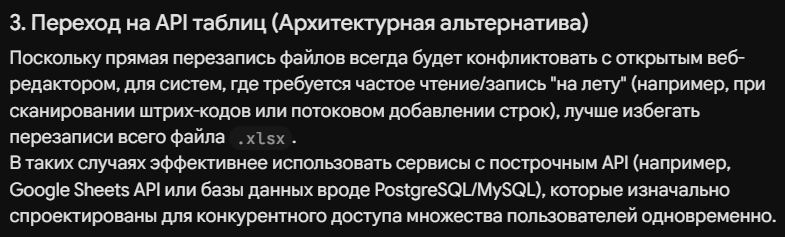](attachment:image.png)

### Чиним добавление

In [ ]:
import io
import os
import time
import openpyxl
import pandas as pd
import yadisk
from dotenv import load_dotenv

# 1. Загрузка конфигурации из .env
load_dotenv()
TOKEN = os.getenv("YANDEX_TOKEN")
DISK_PATH = os.getenv("DISK_PATH")

y = yadisk.YaDisk(token=TOKEN)


def append_row_with_openpyxl(
    disk_path: str, new_row_data: dict, sheet_name=0, retries=3, delay=3
):
    """Скачивает файл с Яндекс.Диска, дописывает новую строку в конкретный лист

    через openpyxl (сохраняя структуру и остальные листы) и отправляет обратно.
    """
    print(f"📥 Скачиваем файл: {disk_path}...")

    # 1. Скачиваем файл в буфер в памяти
    download_buffer = io.BytesIO()
    y.download(disk_path, download_buffer)
    download_buffer.seek(0)

    # 2. Открываем книгу через openpyxl
    wb = openpyxl.load_workbook(download_buffer)

    # 3. Выбираем целевой лист (по имени или индексу)
    if isinstance(sheet_name, int):
        target_sheet_name = wb.sheetnames[sheet_name]
    else:
        target_sheet_name = sheet_name

    if target_sheet_name not in wb.sheetnames:
        raise ValueError(
            f"Лист '{target_sheet_name}' не найден в файле. Доступные листы: {wb.sheetnames}"
        )

    ws = wb[target_sheet_name]

    # 4. Читаем заголовки из первой строки (1-based index в openpyxl)
    headers = [cell.value for cell in ws[1]]

    # 5. Собираем массив значений строго по порядку колонок
    # Если в словаре new_row_data нет какого-то ключа из заголовка — ставится пустая строка ""
    row_to_append = [new_row_data.get(header, "") for header in headers]

    # 6. Добавляем строку в конец листа
    ws.append(row_to_append)
    print(
        f"➕ Строка успешно добавлена на лист «{target_sheet_name}». Всего строк: {ws.max_row}"
    )

    # 7. Сохраняем обновленный файл в новый загрузочный буфер
    upload_buffer = io.BytesIO()
    wb.save(upload_buffer)
    upload_buffer.seek(0)

    # 8. Попытки отправки на Яндекс.Диск с обработкой ошибки блокировки (423 / Locked)
    for attempt in range(1, retries + 1):
        try:
            print(
                f"📤 Загружаем обновленный файл на Яндекс Диск (Попытка {attempt}/{retries})..."
            )
            upload_buffer.seek(0)
            y.upload(upload_buffer, disk_path, overwrite=True)
            print("🎉 Файл успешно обновлен на Яндекс Диске!")
            return

        except yadisk.exceptions.YaDiskError as e:
            error_msg = str(e).lower()
            is_locked = (
                "423" in error_msg
                or "locked" in error_msg
                or "resource is locked" in error_msg
            )

            if is_locked and attempt < retries:
                print(
                    f"⚠️ Файл заблокирован в браузере. Ждем {delay} сек. и пробуем снова..."
                )
                time.sleep(delay)
            else:
                raise Exception(f"❌ Ошибка загрузки (попытка {attempt}): {e}")


# --- Тестовый запуск ---

# Пример данных для добавления
test_item = {
    '№': 1001,
    'Код': '7777777',
    'Код ОКПД2': '00.00.00.0000',
    'Номенклатура': 'Новый предмет',
    'QR код': 'QR-GLEB',
    'Статус': 'На складе',
    'Проект': 'GLEB',
    'Цена': 300,
    'Кол-во': 1,
    'Сумма': 300,
    'Ед. изм.': 'шт',
    'Остаток': 1,
    'Место хранения': 'Лучшее место'
}

try:
    # Можно передавать как номер листа (0 - первый лист), так и его прямое название: "Закупки" или "ОС Главная"
    append_row_with_openpyxl(DISK_PATH, test_item, sheet_name="Закупки")
except Exception as e:
    print(f"❌ Ошибка при выполнении: {e}")

📥 Скачиваем файл: /rkk_test_dataset.xlsx...
➕ Строка успешно добавлена на лист «Закупки». Всего строк: 1002
📤 Загружаем обновленный файл на Яндекс Диск (Попытка 1/3)...
⚠️ Файл заблокирован в браузере. Ждем 3 сек. и пробуем снова...
📤 Загружаем обновленный файл на Яндекс Диск (Попытка 2/3)...
⚠️ Файл заблокирован в браузере. Ждем 3 сек. и пробуем снова...
📤 Загружаем обновленный файл на Яндекс Диск (Попытка 3/3)...
🎉 Файл успешно обновлен на Яндекс Диске!
